## **Histogram Equalization**

Assume `r` donates the intenties of an image, and `r` in range `[0, L-1]` (r = 0 for black and r = L-1 for white)

Transformation (intensity mapping) of the form:
$$ s = T(r), \;\;\; 0 \leq r \leq L-1$$

Under some conditions of T(r):
1. T(r) is a **Monotonic increasing** function in [0, L-1]
2. $0 \leq T(r) \leq L-1$ 
3. T(r) is a **strictly Monotonic increasing** function.

Why this condtions?
1. It will be monotonically increasing guarantees that output intensity values will **never be less** that corresponding input value. 
2. It guarantess that the range of output intensities is **the the same** as the input.
3. it guarantess that mappings from `s` back to `r` will be one-to-one, thus **preventing ambiguities** 

<figure>
  <img src="Images/1_1_image.png" alt="" width="550"/>
  <figcaption>(a) Monotonic increasing function, showing how multiple values can map to a single value.<br>
   (b) Strictly monotonic increasing function.This is a one-to-one mapping, both ways.</figcaption>
</figure>

> This is a theoretical requirement that will allow us to drive some important **histogram processing techniques**.<br>
> because images are stored using integer intensity values, we're forced to round all results to their **nearest integer values**.<br>
> this often results in strict monotonicity not being satisfied, which implies inverse transformations that may not be unique.<br>
> fortunately, this problem isn't difficult to handle in the discrete case.

#### the intensity may be viewed as `random variable` [0, L-1]
- let $P_r(r)$ and $P_s(s)$: the PDFs of the intensity values `r` and `s` in two different images.
- if the $P_r(r)$ and $T(r)$ are known and $T(r)$ is continuous and differentiable.
- $\therefore$ PDF of the transformed variable `s` can be:
$$
P_s(s) = P_r(r)\left|\frac{dr}{ds}\right|
$$
> If you're interested in the mathematical derivation of this result, please refer to **[Approx1](Approx1.ipynb)**

---
> A transformation function:
$$ s = T(r) = (L-1)\; CDF(r) =  (L-1) \int_0^r P_r(w)dw $$

where:
- $w$ is a dummy variable of integration.

this transformation function 
- satisfies condition `1` 
  - because PDFs always positive.
  - and the integral of a function is the area under the function and it can't decrease as r increase.

- satisfies condition `2` 
  - because when the upper limit in the equation is $r = L-1$ the integral = 1, as it must for a PDF.
  - thus, the maximum value of `s` is $L-1$

to find the $ P_s(s) = P_r(r)\left|\frac{dr}{ds}\right| $ corresponding to the transformation function.<br>
**Leibin'z rule**:- the derivative of a definite integral with respect to its upper limit is the integrand evaluated at the limit.
$$
\frac{ds}{dr} = \frac{dT(r)}{dr} = \frac{d}{dr}((L-1) \int_0^r P_r(w)dw)
$$
$$
 = (L-1) \frac{d}{dr}(\int_0^r P_r(w)dw)
$$
$$
 = (L-1) P_r(r)
$$
#### by substituing this result ($\frac{ds}{dr}$ Notice here that it is reversed instead of $\frac{dr}{ds}$)
$$
\therefore P_s(s) = P_r(r)\;\left|\frac{dr}{ds}\right|
$$
$$
= P_r(r)\; . \; \frac{1}{(L-1)\;P_r(r)} 
$$
$$
= \frac{1}{L-1}\;\;\;\;\;\;\;\;\;\;\; 0\leq s \leq L-1
$$
Uniform probability density function

performing the intensity transformation yields a random variable `s` characterized by a unifrom PDF.<br>
$\therefore P_s(s)$ will always be uniform, independently of the form of $P_r(r)$
> If you're interested in how it's always unifrom, please refer to **[Approx2](Approx2.ipynb)**

for discrete values:-
- replace probabilities and summations instead of PDFs and integrals

the discrete form of the transformation function:
$$
s_k = T(r_k) = (L-1) \displaystyle\sum_{j=0}^k P_r(r_j),\;\;\;\;\; k = 0 ... L-1
$$

And this called a `histogram equalization` or `histogram linearization` Transformation.

---

## Theory

Consider an image whose pixel values are confined to a specific range of intensities.  
For example, a **bright image** will have most of its pixel values concentrated in the **higher intensity range**.

However, a **good-quality image** should have pixel values distributed across the **entire intensity range**.  
To achieve this, the image histogram is **stretched toward both ends**, which is exactly what **Histogram Equalization** does.

In simple terms, histogram equalization **redistributes pixel intensities** to enhance the overall **contrast** of the image.

<figure align="center">
  <img src="Images/1_0_image.png" alt="Histogram Equalization Example" width="400"/>
  <figcaption>
    <b>Figure:</b> Histograms of an image before and after histogram equalization.
  </figcaption>
</figure>


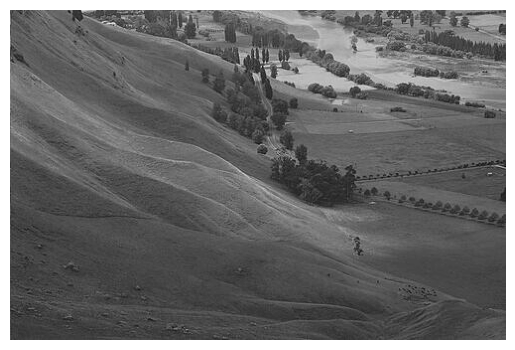

In [1]:
import numpy as np
import cv2 
from matplotlib import pyplot as plt

image = cv2.imread('Images/1_2_image.png', cv2.IMREAD_GRAYSCALE)
assert image is not None, "file could not be read, check with os.path.exists()"

plt.imshow(image, cmap = "gray")
plt.axis("off")
plt.show()

#### Steps : 
1. Compute the histogram.
2. Normalize the histogram (PDF)
3. Compute the CDF.
4. Define the transformation function.
5. Quantization (Discrete case).
6. Map old intensities to new ones.
7. Compute histogram of equalized image

### **1. Compute the histogram:**
counts how many pixels have a given intensity. For intensity level $(r_k)$

$$ h(r_k) = n_k $$
  - for $r_k = 0, 1, 2, ..., L-1$
  - Each intensity level corresponds to a **histogram bin**.

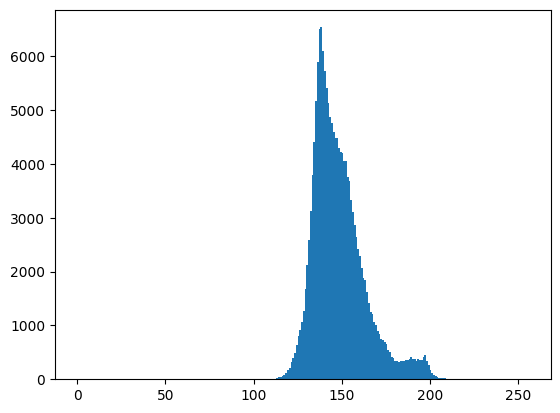

In [2]:
L = 256 # levels of intensity 

hist = cv2.calcHist([image], [0], None, [L],[0,L])
plt.hist(image.ravel(), 256, [0,256])
plt.show()

You can see histogram lies in brighter region. We need the full spectrum. For that, we need a transformation function which maps the input pixels in brighter region to output pixels in full region. That is what histogram equalization does.

### **2. Normalize the histogram (PDF)**:
**Normalized histogram:** fraction of pixels with a given intensity:  

$$p(r_k) = \frac{h(r_k)}{M \times N}$$
  - $M$ = number of rows, $N$ = number of columns in the image
  - Sum of all  $p(r_k)$ values = 1  
  - Represents **probabilities of intensity levels** in the image

In [3]:
num_of_pixels = image.size # M x N
pdf =  hist / num_of_pixels
pdf.shape

(256, 1)

### **3. Compute the CDF**
$$
CDF(r) =  \displaystyle\sum_{j=0}^k P_r(r_j),\;\;\;\;\; k = 0 ... L-1
$$

In [4]:
cdf = np.cumsum(pdf)
cdf.shape

(256,)

### **4. Define the transformation function**
the discrete form of the transformation function:
$$
s_k = T(r_k) = (L-1) \displaystyle\sum_{j=0}^k P_r(r_j),\;\;\;\;\; k = 0 ... L-1
$$


In [5]:
T = (L - 1) * cdf

### **5. Quantization (Discrete case)**

In [6]:
T = np.round(T).astype(np.uint8)

### **6. Map old intensities to new ones**

In [7]:
manual_eq_image = T[image]

### **7. Compute histogram of equalized image**

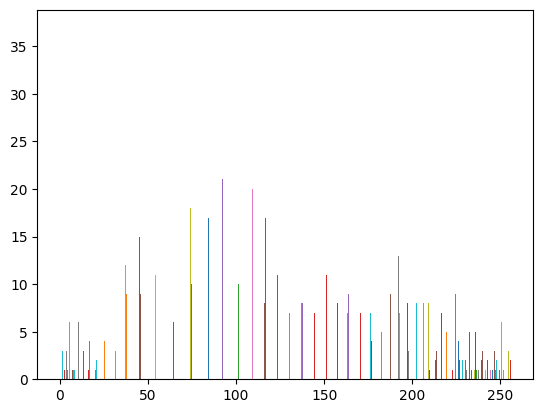

In [8]:
hist_manual = cv2.calcHist([manual_eq_image], [0], None, [L],[0,L])
plt.hist(manual_eq_image, L, [0,L])
plt.show()

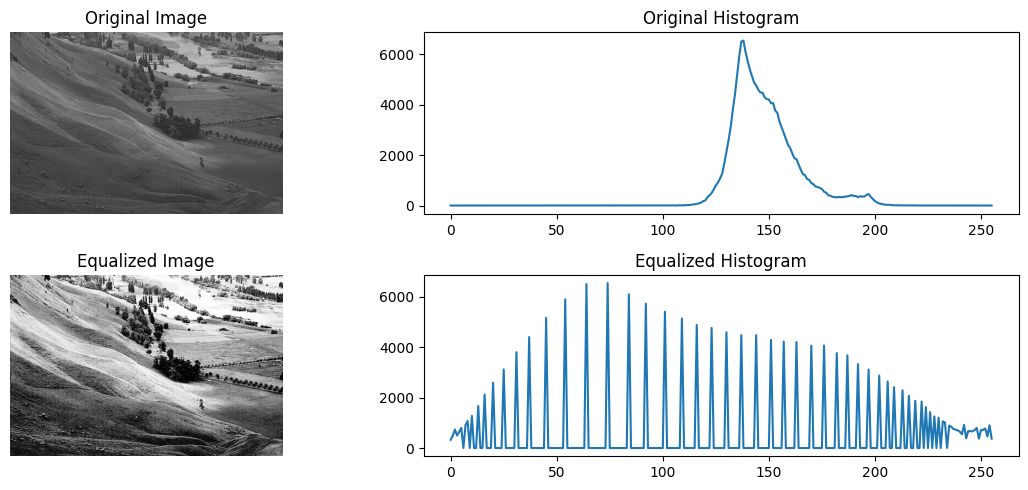

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.plot(hist)
plt.title("Original Histogram")

plt.subplot(2,2,3)
plt.imshow(manual_eq_image, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')

plt.subplot(2,2,4)
plt.plot(hist_manual)
plt.title("Equalized Histogram")

plt.tight_layout()
plt.show()

#### Histogram Equalization Using `OpenCV`
`cv.equalizeHist(src, dst)-> dst`
Equalizes the histogram of a grayscale image.

The function equalizes the histogram of the input image using the following algorithm:
1. Calculate the histogram **H** for src .
2. Normalize the histogram so that the sum of histogram bins is 255.
3. Compute the integral of the histogram: 
$$
H_i^` =  \displaystyle\sum_{0 \leq j < i} H(j)
$$ 

Transform the image using $H^`$ as a look-up table: $dst(x,y) = H^`(src(x,y))$<br>
The algorithm normalizes the brightness and increases the contrast of the image.

Parameters:
- `src`	Source 8-bit single channel image.
- `dst`	Destination image of the same size and type as src.

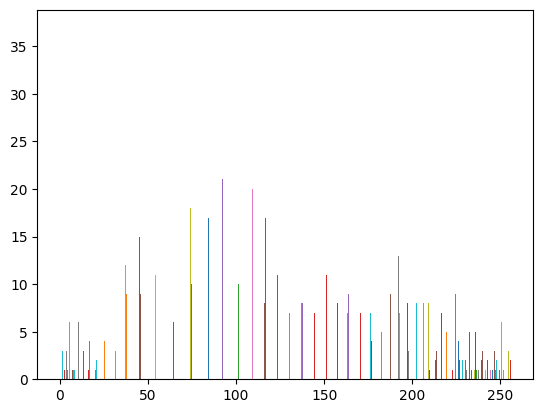

In [10]:
opencv_eq_image = cv2.equalizeHist(image)

hist_cv = cv2.calcHist([opencv_eq_image], [0], None, [L],[0,L])
plt.hist(opencv_eq_image, L, [0,L])
plt.show()

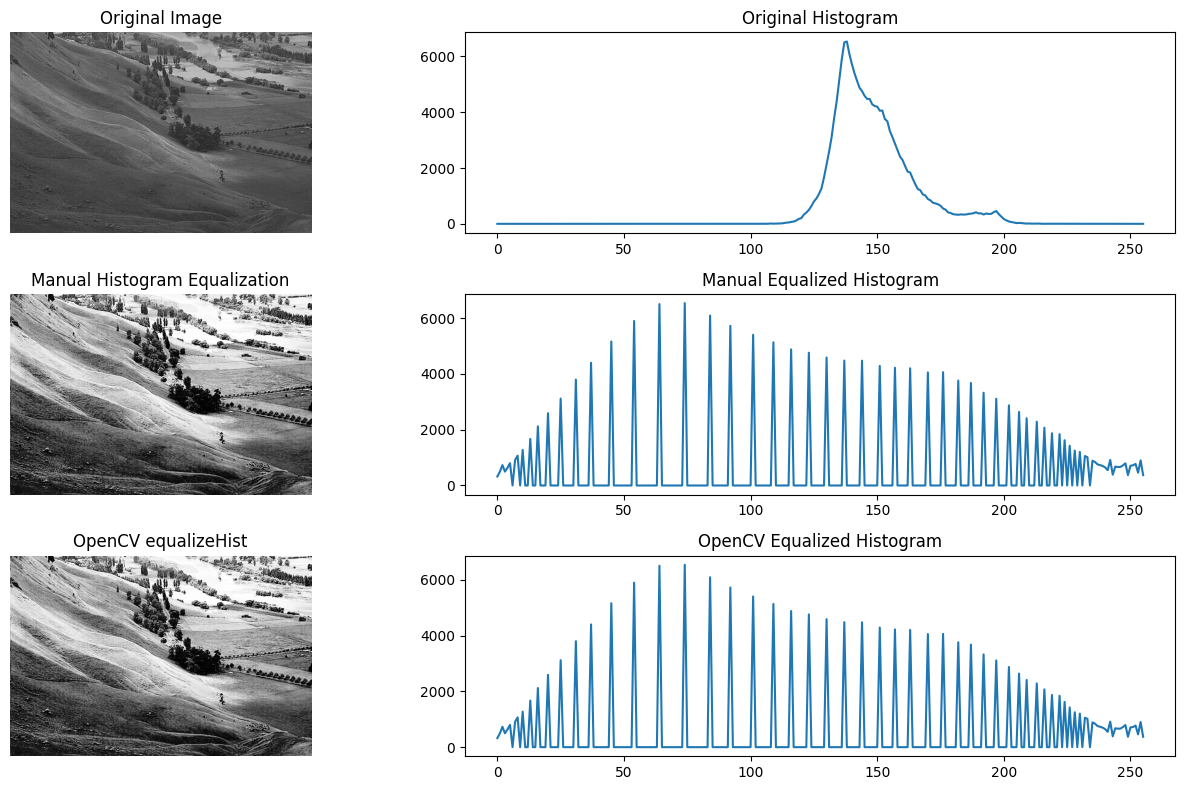

In [11]:
plt.figure(figsize=(14,8))

plt.subplot(3,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(3,2,2)
plt.plot(hist)
plt.title("Original Histogram")

plt.subplot(3,2,3)
plt.imshow(manual_eq_image, cmap='gray')
plt.title("Manual Histogram Equalization")
plt.axis('off')

plt.subplot(3,2,4)
plt.plot(hist_manual)
plt.title("Manual Equalized Histogram")

plt.subplot(3,2,5)
plt.imshow(opencv_eq_image, cmap='gray')
plt.title("OpenCV equalizeHist")
plt.axis('off')

plt.subplot(3,2,6)
plt.plot(hist_cv)
plt.title("OpenCV Equalized Histogram")

plt.tight_layout()
plt.show()

In [12]:
np.max(np.abs(manual_eq_image.astype(int) - opencv_eq_image.astype(int)))

0

The manually implemented histogram equalization produces identical results to OpenCV’s `equalizeHist`, confirming the correctness of the theoretical transformation and its discrete implementation.